In [20]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.grid'] = True

# Load the dataset
df = pd.read_csv('spotify_emeritus.csv')
print(f"Dataset shape: {df.shape}")

# Display basic information about the dataset
print("\nDataset Info:")
df.info()

# Display first few rows
print("\nFirst few rows:")
df.head()


Dataset shape: (114000, 21)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Data Quality Check

In [21]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Handle missing values if any
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print(f"\nShape after removing missing values: {df.shape}")

# Remove unnecessary columns
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("Dropped 'Unnamed: 0' column")


Missing values in each column:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Shape after removing missing values: (113999, 21)
Dropped 'Unnamed: 0' column


In [22]:
# Basic statistics for numerical columns
print("Basic statistics for numerical features:")
print(df.describe(include='all'))

# Count of categorical values
print("\nGenre distribution:")
print(df['track_genre'].value_counts().head())

print("\nExplicit vs Non-explicit songs:")
print(df['explicit'].value_counts())


Basic statistics for numerical features:
                      track_id      artists                  album_name  \
count                   113999       113999                      113999   
unique                   89740        31437                       46589   
top     6S3JlDAGk3uu3NtZbPnuhS  The Beatles  Alternative Christmas 2022   
freq                         9          279                         195   
mean                       NaN          NaN                         NaN   
std                        NaN          NaN                         NaN   
min                        NaN          NaN                         NaN   
25%                        NaN          NaN                         NaN   
50%                        NaN          NaN                         NaN   
75%                        NaN          NaN                         NaN   
max                        NaN          NaN                         NaN   

             track_name     popularity   duration_ms expli

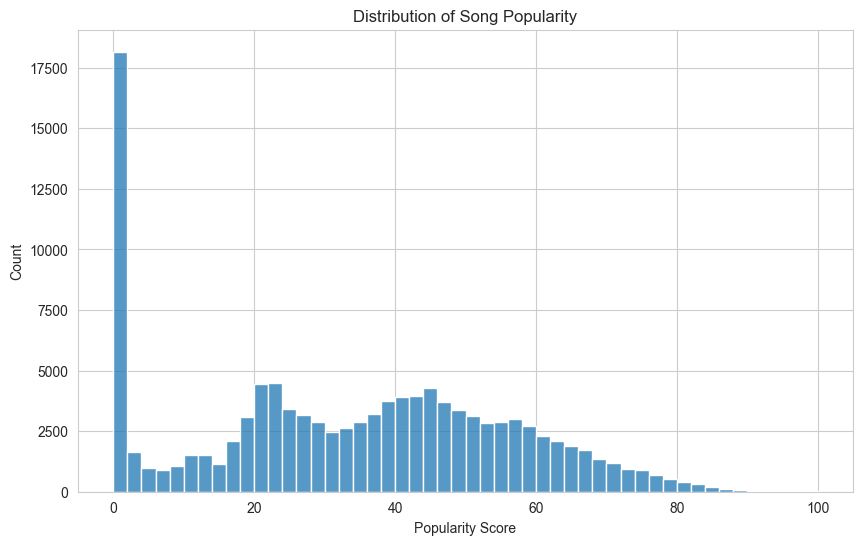

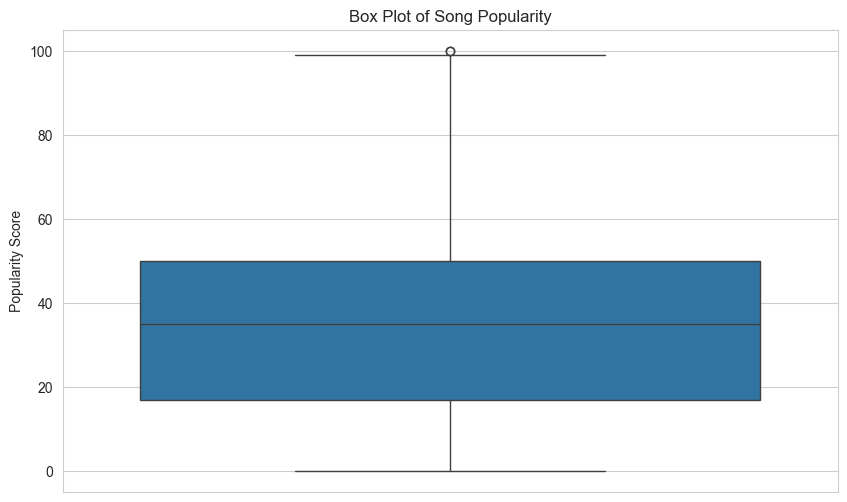

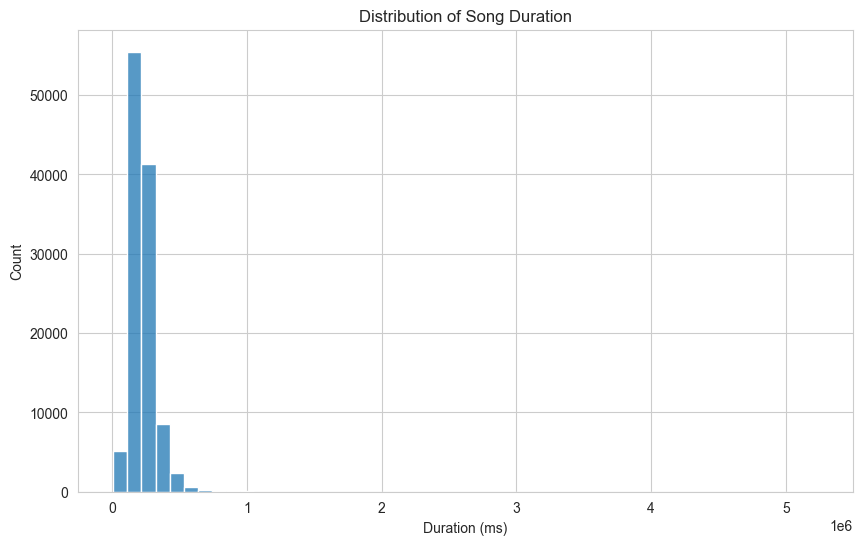

In [23]:
# Popularity distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='popularity', bins=50)
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Count')
plt.show()

# Box plot of popularity
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['popularity'])
plt.title('Box Plot of Song Popularity')
plt.ylabel('Popularity Score')
plt.show()

# Duration distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='duration_ms', bins=50)
plt.title('Distribution of Song Duration')
plt.xlabel('Duration (ms)')
plt.ylabel('Count')
plt.show()


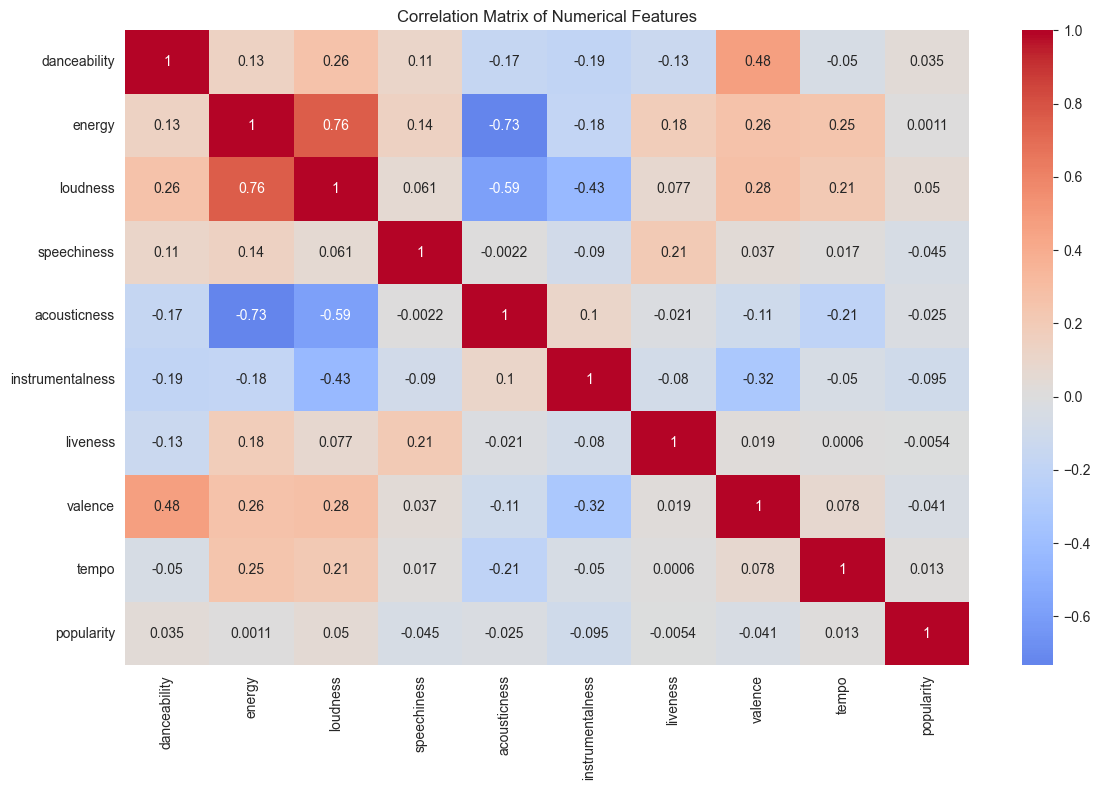

In [24]:
# Select numerical features
numerical_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                     'acousticness', 'instrumentalness', 'liveness', 'valence', 
                     'tempo', 'popularity']

# Correlation matrix
correlation_matrix = df[numerical_features].corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


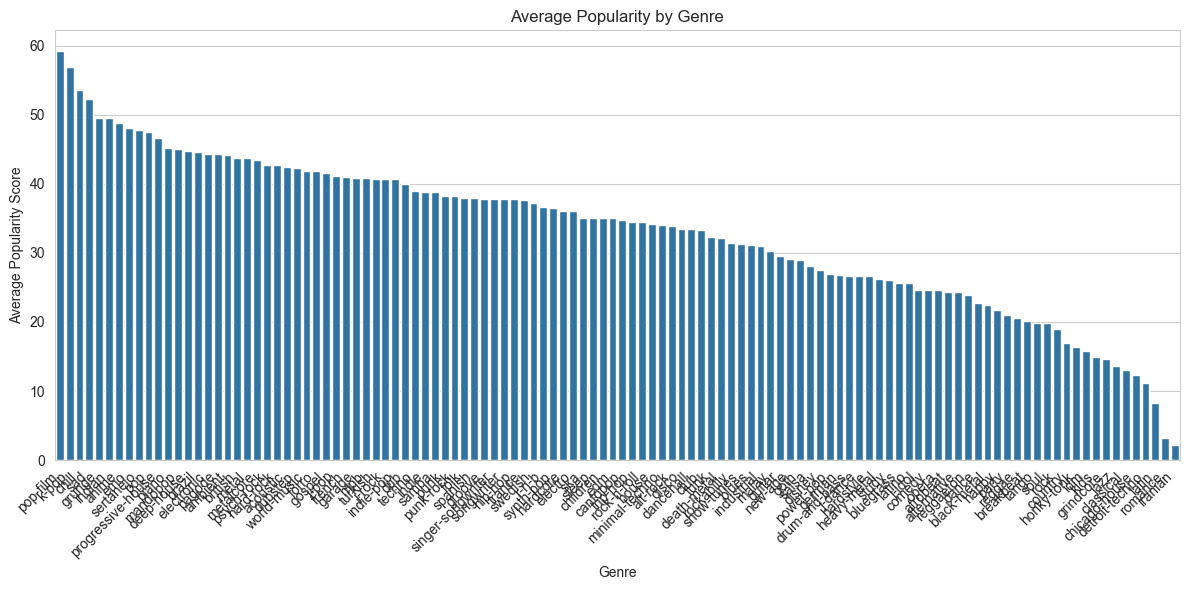

In [25]:
# Calculate mean popularity by genre
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_popularity.index, y=genre_popularity.values)
plt.xticks(rotation=45, ha='right')
plt.title('Average Popularity by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Popularity Score')
plt.tight_layout()
plt.show()


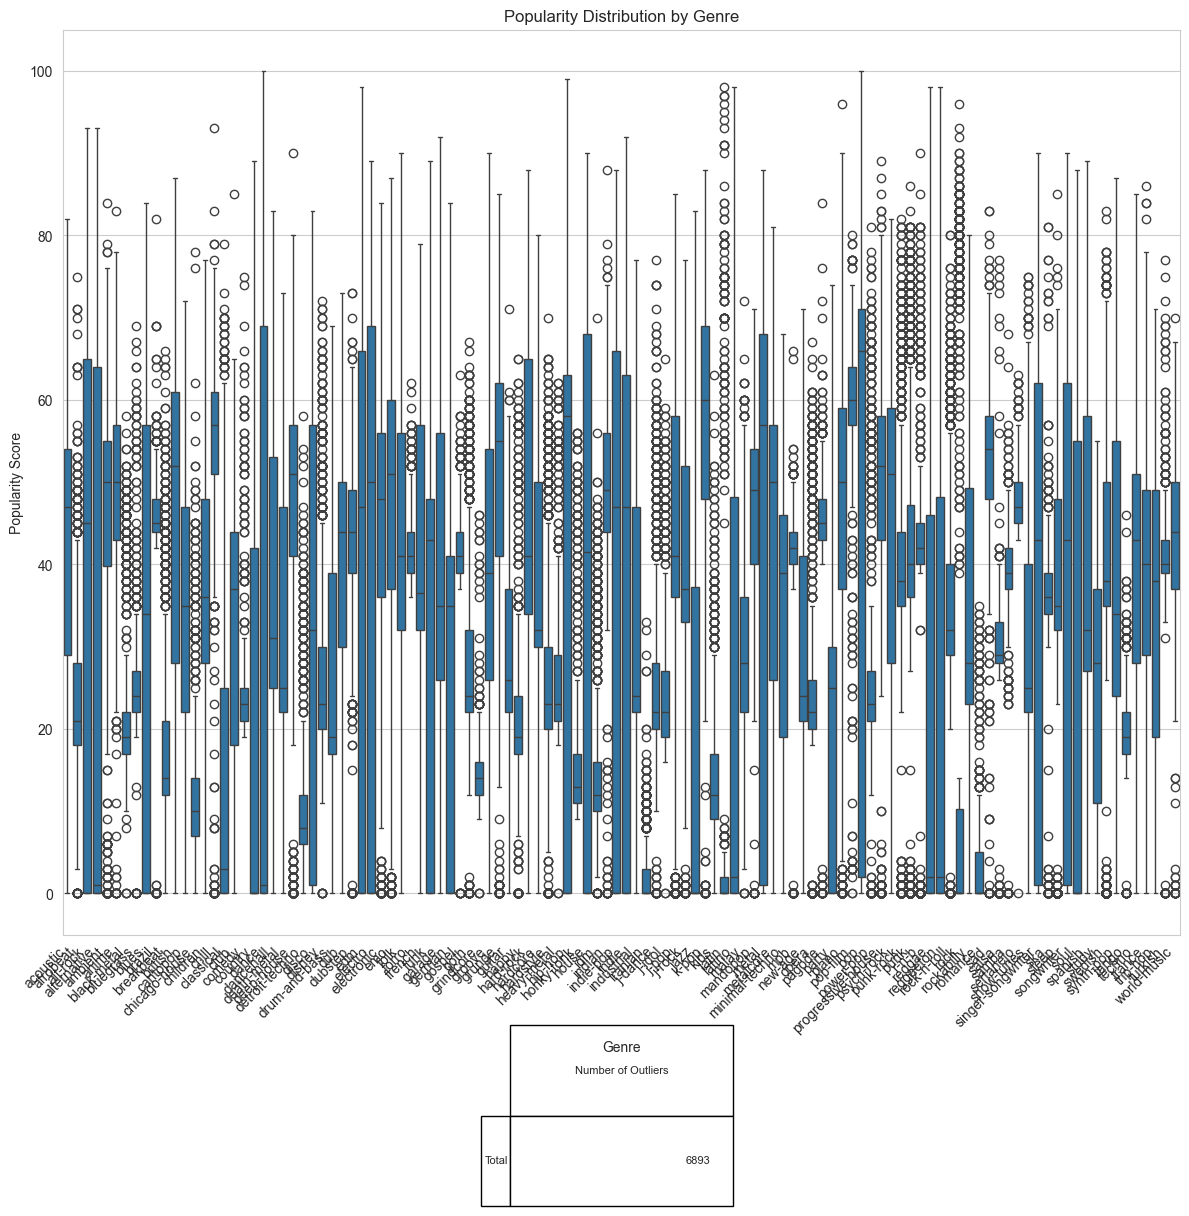

In [26]:
# Calculate outliers for each genre
outliers_by_genre = {}
for genre in df['track_genre'].unique():
    genre_data = df[df['track_genre'] == genre]['popularity']
    q1 = genre_data.quantile(0.25)
    q3 = genre_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = genre_data[(genre_data < lower_bound) | (genre_data > upper_bound)]
    outliers_by_genre[genre] = len(outliers)

# Create boxplot of popularity by genre
plt.figure(figsize=(12, 12))
sns.boxplot(x='track_genre', y='popularity', data=df)
plt.xticks(rotation=45, ha='right')

# Create a table of total outliers
total_outliers = sum(outliers_by_genre.values())
outliers_table = plt.table(
    cellText=[[f"{total_outliers}"]],
    rowLabels=['Total'],
    colLabels=['Number of Outliers'],
    loc='bottom',
    bbox=[0.4, -0.3, 0.2, 0.2]  # [left, bottom, width, height] - reduced size since only one row
)
outliers_table.auto_set_font_size(False)
outliers_table.set_fontsize(8)
plt.subplots_adjust(bottom=0.2)  # Reduced bottom margin since table is smaller

plt.title('Popularity Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.show()


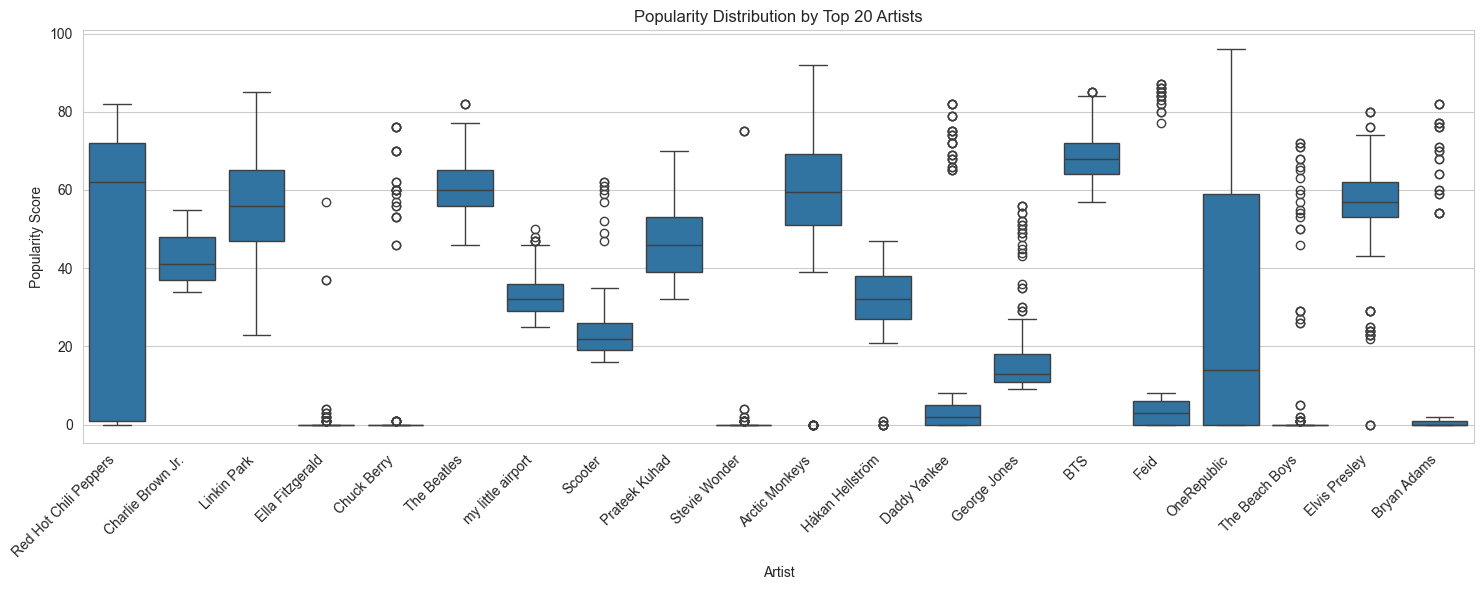

In [27]:
# Get top 20 artists by number of tracks
top_artists = df['artists'].value_counts().head(20).index

# Filter dataframe for top artists
df_top_artists = df[df['artists'].isin(top_artists)]

# Create boxplot
plt.figure(figsize=(15, 6))
sns.boxplot(x='artists', y='popularity', data=df_top_artists)
plt.xticks(rotation=45, ha='right')
plt.title('Popularity Distribution by Top 20 Artists')
plt.xlabel('Artist')
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.show()


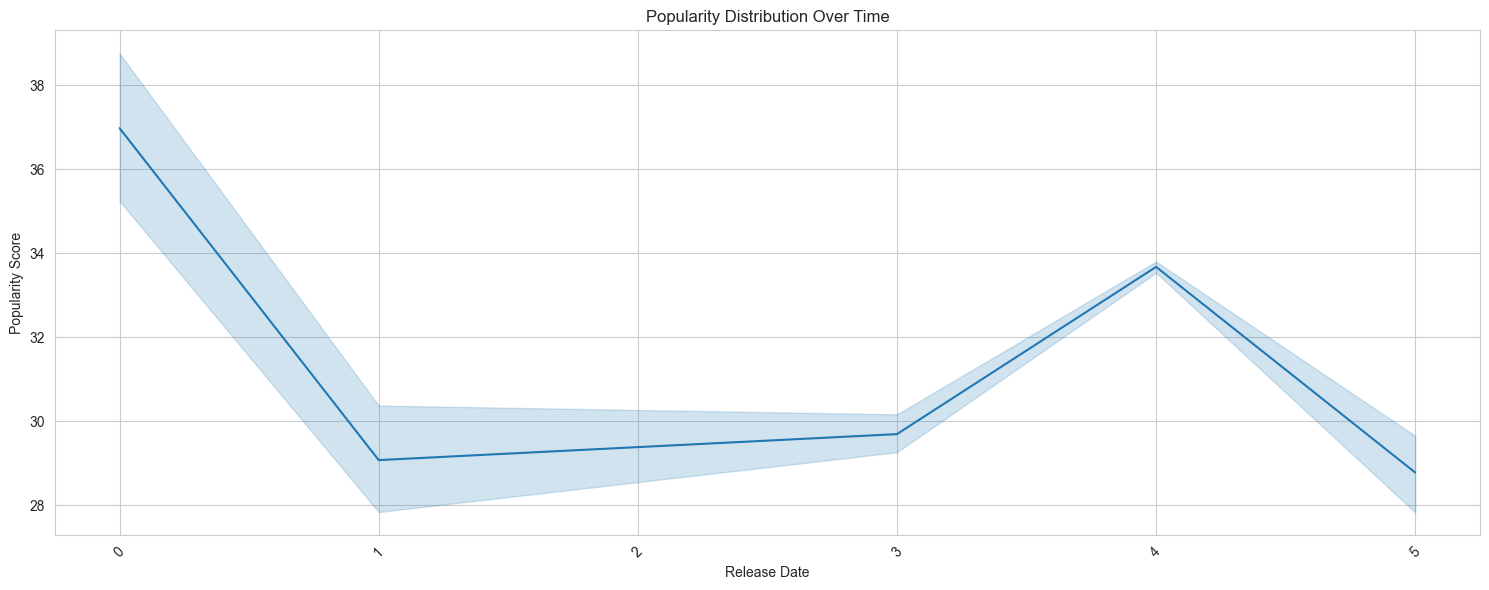

In [29]:
# Convert release_date to datetime if not alread
# Create line plot of popularity over time
plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x='time_signature', y='popularity')
plt.title('Popularity Distribution Over Time')
plt.xlabel('Release Date') 
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


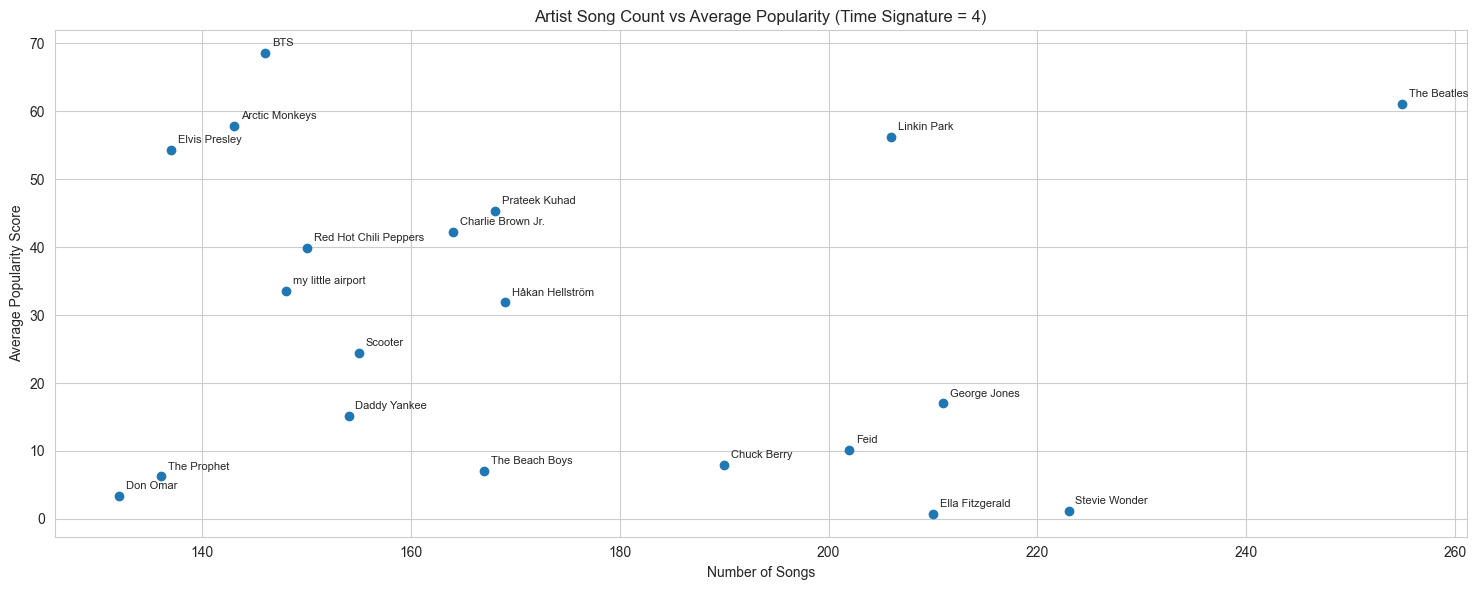

In [31]:
# Filter for time signature of 4
df_time_4 = df[df['time_signature'] == 4]

# Calculate song counts and mean popularity per artist
artist_stats = df_time_4.groupby('artists').agg({
    'track_id': 'count',
    'popularity': 'mean'
}).reset_index()

# Sort by song count and get top 20
artist_stats = artist_stats.sort_values('track_id', ascending=False).head(20)

# Create scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(artist_stats['track_id'], artist_stats['popularity'])

# Add artist labels to points
for idx, row in artist_stats.iterrows():
    plt.annotate(row['artists'], (row['track_id'], row['popularity']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.title('Artist Song Count vs Average Popularity (Time Signature = 4)')
plt.xlabel('Number of Songs')
plt.ylabel('Average Popularity Score')
plt.tight_layout()
plt.show()


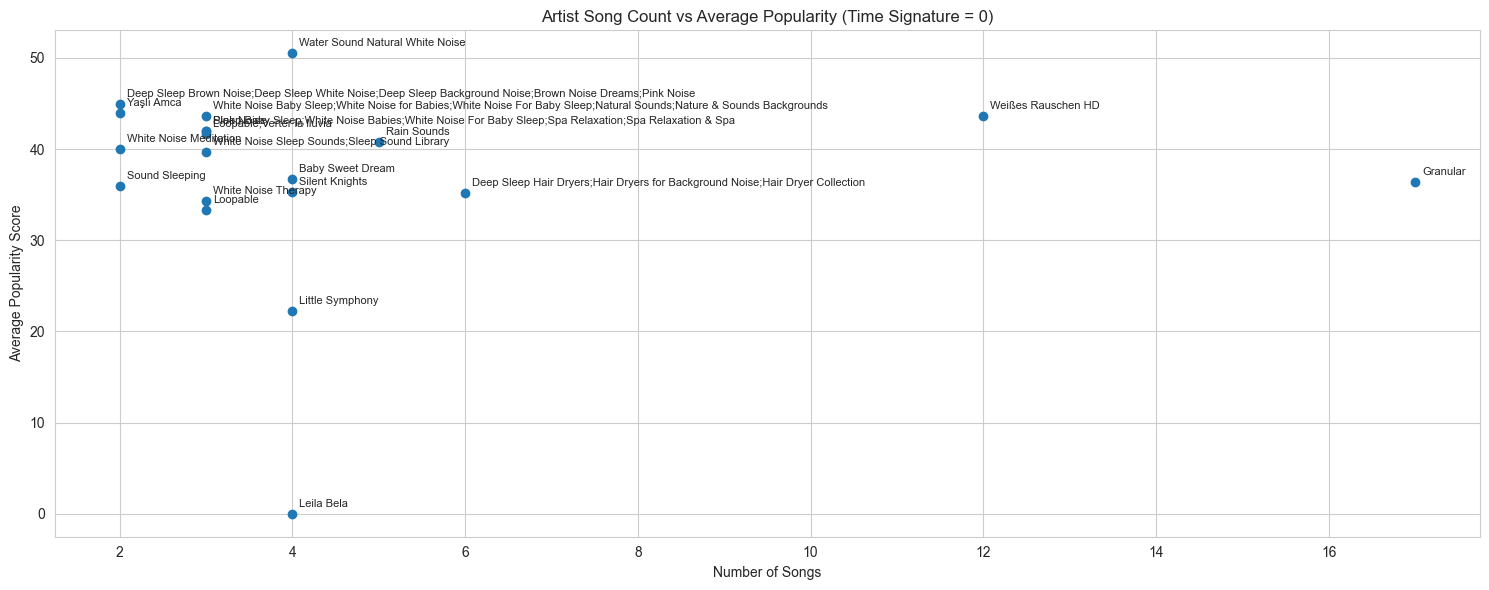

In [33]:
# Filter for time signature of 4
df_time_4 = df[df['time_signature'] == 0]

# Calculate song counts and mean popularity per artist
artist_stats = df_time_4.groupby('artists').agg({
    'track_id': 'count',
    'popularity': 'mean'
}).reset_index()

# Sort by song count and get top 20
artist_stats = artist_stats.sort_values('track_id', ascending=False).head(20)

# Create scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(artist_stats['track_id'], artist_stats['popularity'])

# Add artist labels to points
for idx, row in artist_stats.iterrows():
    plt.annotate(row['artists'], (row['track_id'], row['popularity']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.title('Artist Song Count vs Average Popularity (Time Signature = 0)')
plt.xlabel('Number of Songs')
plt.ylabel('Average Popularity Score')
plt.tight_layout()
plt.show()


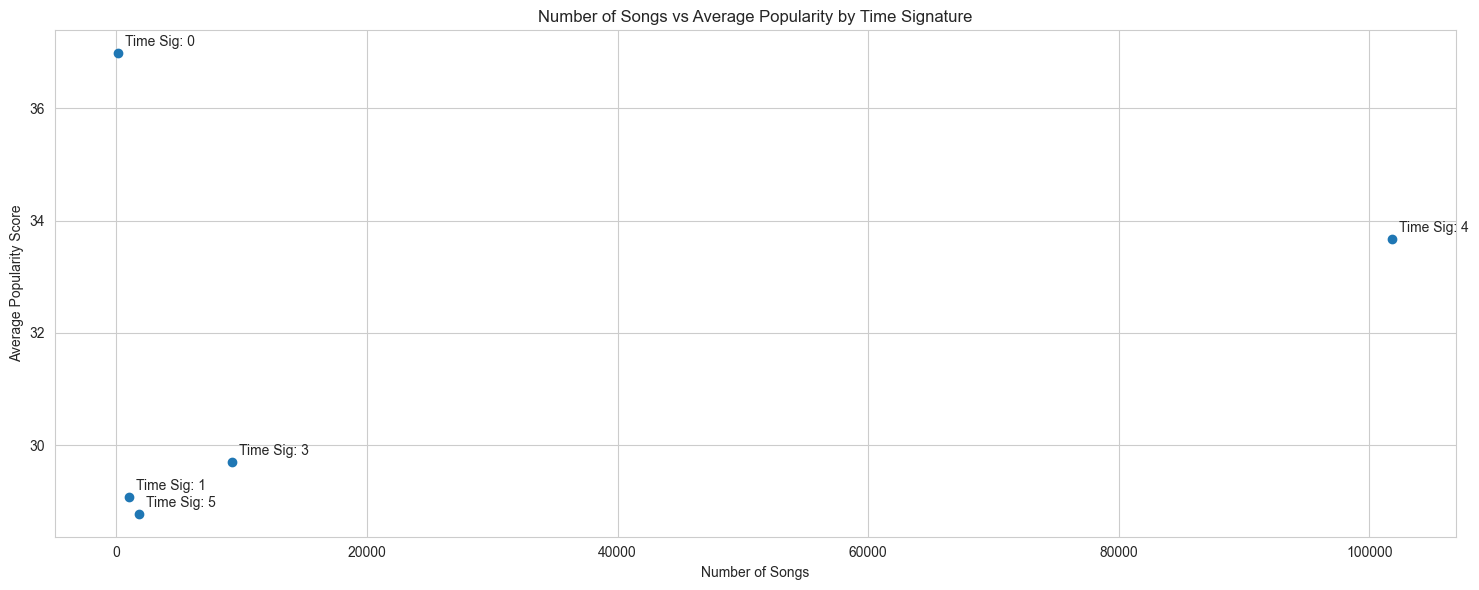

In [37]:
# Calculate song counts and mean popularity per time signature
time_sig_stats = df.groupby('time_signature').agg({
    'track_id': 'count',
    'popularity': 'mean'
}).reset_index()

# Create scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(time_sig_stats['track_id'], time_sig_stats['popularity'])

# Add time signature labels to points
for idx, row in time_sig_stats.iterrows():
    plt.annotate(f"Time Sig: {int(row['time_signature'])}", 
                (row['track_id'], row['popularity']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.title('Number of Songs vs Average Popularity by Time Signature')
plt.xlabel('Number of Songs')
plt.ylabel('Average Popularity Score')
plt.tight_layout()
plt.show()
